In [10]:
from wrapper import BasicEnvironmentRGB
import gymnasium as gym
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
import numpy as np
import torch


env = gym.make('Acrobot-v1', render_mode="rgb_array")
env = BasicEnvironmentRGB(env)
buffer_shapes = [(64, 64, 3), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=10_000)

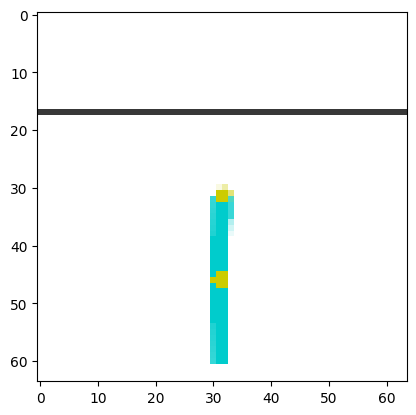

In [11]:
obs, _ = env.reset()
plt.imshow(obs)

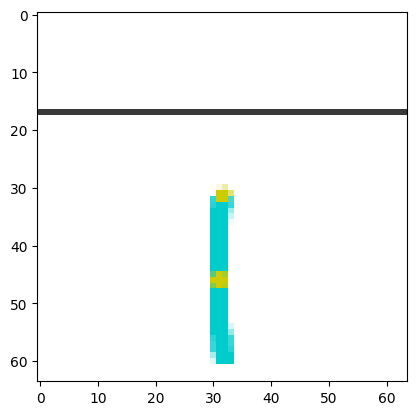

In [12]:
obs, _, _, _, _ = env.step(2)
plt.imshow(obs)

In [13]:
samples = random_sample_single_env(env, num_steps=5000)
for i in range(5000):
    buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())

In [23]:
from fundamental_variable_discovery import Encoder, Decoder

encoder = Encoder().cuda()
decoder = Decoder(encoder.conv_dim).cuda()
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 1e-4)


In [ ]:
losses = []
for _ in range(5000):
    samples = buffer.sample(512)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    latent = encoder(obs)
    reconstruction = decoder(latent)
    loss = torch.nn.functional.mse_loss(reconstruction, obs)
    loss.backward()
    opt.step()
    opt.zero_grad()
    losses.append(loss.detach().cpu().numpy())

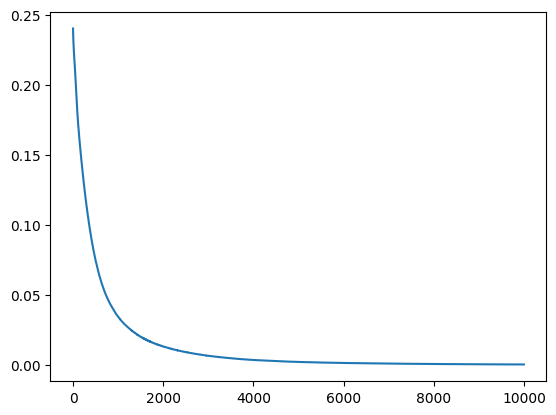

In [25]:
plt.plot(losses)

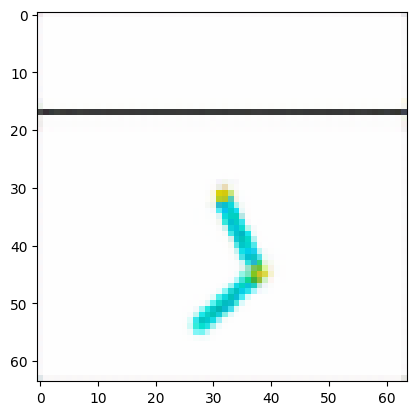

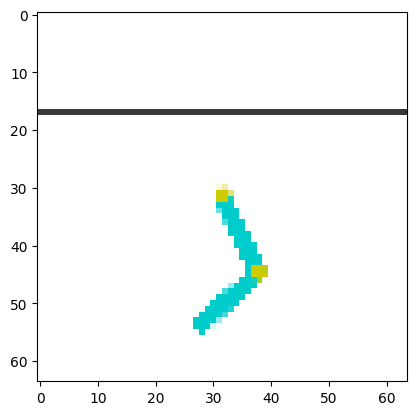

In [26]:
plt.imshow(reconstruction[0].detach().cpu().transpose(-3, -1).numpy())
plt.show()
plt.imshow(samples[0][0])